# WOCAT — Getting and Exploring the Data

_This notebook downloads the WOCAT Sustainable Land Management database, builds a tidy table from it, and looks at it from enough angles to decide what a machine learning project could realistically do with it._

<table align="left">
  <td>
    <a href="https://colab.research.google.com/github/YOUR_GITHUB_USERNAME/YOUR_REPO/blob/main/colab/01_wocat_explore.ipynb">
      <img src="https://colab.research.google.com/assets/colab-badge.svg" />Run in Google Colab</a>
  </td>
</table>

# Setup

This project requires Python 3.9 or above:

In [1]:
import sys

assert sys.version_info >= (3, 9)

It also requires Scikit-Learn ≥ 1.0.1 (only used at the very end):

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

If you are running this in Colab, the next cell installs the few extra packages that are not
preinstalled there, and does nothing when you run the notebook locally:

In [3]:
if "google.colab" in sys.modules:
    %pip install -q -U requests pandas matplotlib

As in the rest of this project, let's define the default font sizes to make the figures prettier:

In [4]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=12, titlesize=13)
plt.rc('legend', fontsize=11)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Matplotlib is building the font cache; this may take a moment.


And let's create the `images/wocat` folder (if it doesn't already exist), and define the
`save_fig()` function which is used through this notebook to save the figures in high-res:

In [5]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "wocat"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# 1. Get the Data

## 1.1 What WOCAT is

[WOCAT](https://wocat.net) is a global network documenting **Sustainable Land Management (SLM)**
practices. Its database holds standardised questionnaires filled in by practitioners around the
world. Each *technology* record describes one practice: where it is used, what the site is like,
what was done, what it cost, and what the compiler reports as its impacts.

The REST API is documented at [wocat.net/api/database/redoc](https://wocat.net/api/database/redoc/).
Two things about it shape everything below:

* Every request needs a **token** in an `Authorization: Token …` header. You get one by emailing
  the WOCAT secretariat (wocat.cde@unibe.ch).
* The **list** endpoint returns 30 summary fields per record, but the biodiversity, impact and cost
  data only exist on the **detail** endpoint (~190 fields). So we need one request *per technology*.
  There are about 1,500 of them, which takes a couple of minutes.

## 1.2 Authentication

Never paste a token into a notebook you intend to commit. The function below looks for it in three
places, in order of preference:

1. **Colab Secrets** (the 🔑 icon in the left sidebar) — add a secret named `WOCAT_TOKEN`.
2. A `WOCAT_TOKEN` environment variable, or a `.env` file next to the notebook.
3. An interactive prompt, as a last resort.

In [6]:
import os

def find_wocat_token():
    """Look for the token, but never prompt — returns None if it isn't around."""
    # 1. Colab Secrets
    if "google.colab" in sys.modules:
        try:
            from google.colab import userdata
            return userdata.get("WOCAT_TOKEN")
        except Exception:
            pass  # secret not set, or access not granted — fall through

    # 2. Environment variable, or a .env file in this directory or its parent
    if os.environ.get("WOCAT_TOKEN"):
        return os.environ["WOCAT_TOKEN"]
    for env_file in [Path(".env"), Path("..") / ".env"]:
        if env_file.is_file():
            for line in env_file.read_text().splitlines():
                if line.startswith("WOCAT_TOKEN="):
                    return line.split("=", 1)[1].strip().strip('"').strip("'")
    return None

WOCAT_TOKEN = find_wocat_token()
print("token found" if WOCAT_TOKEN else
      "no token found — fine if the cached CSVs are present, otherwise you'll be asked for one")

no token found — fine if the cached CSVs are present, otherwise you'll be asked for one


## 1.3 Downloading

The function below is written the way most data-fetching functions in this project are: it caches
to disk, so it only hits the network the first time. Running the notebook again — or restarting a
Colab session after committing `datasets/wocat/` — is instant.

The detail requests are made in a small thread pool. Six workers is polite and takes about two
minutes; there is no reason to go faster.

In [7]:
import gzip
import json
import requests
from concurrent.futures import ThreadPoolExecutor

WOCAT_URL = "https://wocat.net/api/database"
DATA_PATH = Path() / "datasets" / "wocat"

def wocat_session():
    """Build an authenticated session, asking for the token only if we really need it."""
    global WOCAT_TOKEN
    if not WOCAT_TOKEN:
        from getpass import getpass
        WOCAT_TOKEN = getpass("WOCAT API token: ")
    session = requests.Session()
    session.headers.update({"Authorization": f"Token {WOCAT_TOKEN}",
                            "Accept": "application/json"})
    return session

def fetch_wocat_records(workers=6):
    """Download every technology record. Cached as one gzipped JSON file."""
    DATA_PATH.mkdir(parents=True, exist_ok=True)
    cache = DATA_PATH / "technologies_raw.json.gz"
    if cache.is_file():
        with gzip.open(cache, "rt", encoding="utf-8") as f:
            return json.load(f)

    session = wocat_session()
    summaries = session.get(f"{WOCAT_URL}/technologies/", timeout=120).json()
    print(f"{len(summaries)} technologies listed; fetching full records...")

    def fetch_one(tech_id):
        response = session.get(f"{WOCAT_URL}/technologies/{tech_id}/", timeout=60)
        return response.json() if response.ok else None

    with ThreadPoolExecutor(max_workers=workers) as pool:
        records = list(pool.map(fetch_one, [s["id"] for s in summaries]))
    records = [r for r in records if r is not None]

    with gzip.open(cache, "wt", encoding="utf-8") as f:
        json.dump(records, f, ensure_ascii=False)
    return records

def fetch_wocat_countries():
    """alpha-2 code -> country name."""
    DATA_PATH.mkdir(parents=True, exist_ok=True)
    cache = DATA_PATH / "countries.json"
    if not cache.is_file():
        cache.write_text(json.dumps(wocat_session().get(f"{WOCAT_URL}/countries/", timeout=60).json()))
    return {c["alpha2"].upper(): c["name"] for c in json.loads(cache.read_text()) if c.get("alpha2")}

## 1.4 Building a tidy table

The questionnaire is deeply nested, multilingual, and mostly multiple-choice. Three helpers deal
with the three recurring shapes:

* Free text is a `{language_code: text}` dictionary — `pick_text()` prefers English.
* Multiple-choice answers are lists — we keep both a joined string and the first choice.
* Impact blocks are `{indicator: {"value": -3…+3, …}}` — `impact_mean()` averages the scored ones.

In [8]:
import numpy as np
import pandas as pd

IMPACT_BLOCKS = ["impacts_socio_economic_production", "impacts_socio_economic_income",
                 "impacts_socio_economic_water", "impacts_socio_cultural",
                 "impacts_ecological_soil", "impacts_ecological_water",
                 "impacts_ecological_biodiversity", "impacts_ecological_climate",
                 "impacts_offsite"]

TEXT_FIELDS = ["description", "definition", "strengths_compiler", "weaknesses_compiler",
               "strengths_landuser", "weaknesses_landuser", "establishment_activities",
               "maintenance_activities", "landuse_comments", "degradation_comments",
               "soil_comments", "adoption_comments", "biodiversity_comments"]

def pick_text(value, prefer="en"):
    """WOCAT free text is {lang: text}. Prefer English, else anything non-empty."""
    if not isinstance(value, dict) or not value:
        return None
    if value.get(prefer):
        return value[prefer]
    return next((v for v in value.values() if isinstance(v, str) and v.strip()), None)

def count_words(value):
    """Total words in a field, which may be text, a list of texts, or nested dicts."""
    total = 0
    def walk(node):
        nonlocal total
        if isinstance(node, dict):
            keys = set(node)
            if keys and all(isinstance(k, str) and len(k) <= 3 for k in keys):
                text = pick_text(node)
                total += len(text.split()) if text else 0
            else:
                for v in node.values():
                    walk(v)
        elif isinstance(node, list):
            for v in node:
                walk(v)
    walk(value)
    return total

def impact_mean(version, block):
    """Mean of the -3..+3 scores a compiler gave in one impact block."""
    data = version.get(block)
    if not isinstance(data, dict):
        return np.nan
    scores = [e["value"] for e in data.values()
              if isinstance(e, dict) and isinstance(e.get("value"), int)]
    return np.mean(scores) if scores else np.nan

def joined(values):
    return "|".join(values) if values else None

def first(values):
    return values[0] if values else None

In [9]:
def build_dataframe(records, countries):
    rows = []
    for record in records:
        v = record["selected_version"]
        landuse = v.get("landuse") or {}
        measures = v.get("slm_measures") or {}
        degradation = v.get("degradation") or {}
        geometry = v.get("location_geometry") or {}
        points = [c for c in (geometry.get("coordinates") or [])
                  if isinstance(c, (list, tuple)) and len(c) >= 2]

        row = {
            "technology_id": record["id"],
            "name": pick_text(v.get("name")),
            "country": v.get("country"),
            "country_name": countries.get(v.get("country")),
            "latitude": np.mean([p[1] for p in points]) if points else np.nan,
            "longitude": np.mean([p[0] for p in points]) if points else np.nan,
            "edition": v.get("edition"),
            "published": record.get("first_published_at"),
            "primary_language": v.get("primary_language"),
            "n_languages": len(v.get("languages") or []),
            "compiler_id": v.get("compiler_id"),
            "n_approaches": len(record.get("approaches") or []),
            # --- environment -------------------------------------------------
            "agroclimatic_zone": first(v.get("agroclimatic_zone")),
            "rainfall": first(v.get("rainfall")),
            "altitude": first(v.get("altitudinalzone")),
            "slope": first(v.get("slopes")),
            "landform": first(v.get("landforms")),
            "soil_depth": first(v.get("soil_depth")),
            "soil_texture": first(v.get("soil_texture_topsoil")),
            "topsoil_organic": first(v.get("topsoil_organic")),
            "watersupply": v.get("watersupply"),
            # --- what the land is used for and what was done ------------------
            "landuse": joined(landuse.get("value")),
            "landuse_primary": first(landuse.get("value")),
            "slm_group": joined(v.get("slm_group")),
            "slm_group_primary": first(v.get("slm_group")),
            "measures": joined(measures.get("value")),
            "measure_primary": first(measures.get("value")),
            "main_purpose": joined(v.get("main_purpose")),
            "degradation": joined(degradation.get("value")),
            "degradation_primary": first(degradation.get("value")),
            # --- socio-economic ------------------------------------------------
            "market_orientation": first(v.get("market_orientation")),
            "mechanisation": first(v.get("mechanisation")),
            "land_size": first(v.get("land_size")),
            "wealth": first(v.get("wealth")),
            "costbenefit_short": v.get("costbenefit_establishment_short"),
            "adoption": v.get("adoption_spontaneously"),
            # --- modalities -----------------------------------------------------
            "n_images": len(v.get("images") or []),
            "n_drawings": len(v.get("technical_drawings") or []),
            "description_words": len((pick_text(v.get("description")) or "").split()),
            "description_en": bool((v.get("description") or {}).get("en")),
            "total_text_words": sum(count_words(v.get(f)) for f in TEXT_FIELDS),
        }

        # --- the impact questionnaire: one mean per block, plus a total count ---
        n_scores = 0
        for block in IMPACT_BLOCKS:
            row["imp_" + block.replace("impacts_", "")] = impact_mean(v, block)
            data = v.get(block)
            if isinstance(data, dict):
                n_scores += sum(1 for e in data.values()
                                if isinstance(e, dict) and isinstance(e.get("value"), int))
        row["n_impact_scores"] = n_scores
        rows.append(row)

    return pd.DataFrame(rows).sort_values("technology_id").reset_index(drop=True)

def build_impacts_long(records):
    """One row per individual -3..+3 score, which is what section 7 needs."""
    rows = []
    for record in records:
        version = record["selected_version"]
        for block in IMPACT_BLOCKS:
            data = version.get(block)
            if not isinstance(data, dict):
                continue
            for indicator, entry in data.items():
                if isinstance(entry, dict) and isinstance(entry.get("value"), int):
                    rows.append({"technology_id": record["id"],
                                 "block": block.replace("impacts_", ""),
                                 "indicator": indicator,
                                 "value": entry["value"]})
    return pd.DataFrame(rows)

## 1.5 Load it

One function ties it together. It prefers the two small CSVs, so if they are committed to the
repository the notebook opens in Colab and runs **without a token at all**. Only when they are
missing does it hit the API — which is when you need one.

In [10]:
FLAT_CSV = DATA_PATH / "wocat_technologies.csv.gz"
LONG_CSV = DATA_PATH / "impact_scores.csv.gz"
SAMPLE_JSON = DATA_PATH / "sample_records.json"

def load_wocat():
    """Return (tidy table, one-row-per-score table, a few raw records for inspection)."""
    if FLAT_CSV.is_file() and LONG_CSV.is_file():
        print("loading the cached CSVs (no token needed)")
        sample = json.loads(SAMPLE_JSON.read_text()) if SAMPLE_JSON.is_file() else None
        return pd.read_csv(FLAT_CSV), pd.read_csv(LONG_CSV), sample

    print("no cached CSVs — downloading from the API")
    records = fetch_wocat_records()
    countries = fetch_wocat_countries()
    flat = build_dataframe(records, countries)
    long = build_impacts_long(records)

    DATA_PATH.mkdir(parents=True, exist_ok=True)
    flat.to_csv(FLAT_CSV, index=False, compression="gzip")
    long.to_csv(LONG_CSV, index=False, compression="gzip")
    # a handful of raw records, so the nested structure stays inspectable offline
    SAMPLE_JSON.write_text(json.dumps(records[:3], ensure_ascii=False))
    return flat, long, records[:3]

wocat, impact_scores, sample_records = load_wocat()
print(f"{wocat.shape[0]} technologies x {wocat.shape[1]} columns, "
      f"{len(impact_scores):,} individual impact scores")

loading the cached CSVs (no token needed)
1540 technologies x 51 columns, 23,802 individual impact scores


Each record has a small envelope and a big `selected_version` holding the actual questionnaire.
A few raw records are cached alongside the CSVs so the nested structure stays inspectable:

In [11]:
if sample_records:
    record = sample_records[0]
    print("envelope keys:", list(record.keys()))
    print()
    print(f"selected_version has {len(record['selected_version'])} fields, for example:")
    print(sorted(record["selected_version"])[:24])

envelope keys: ['id', 'selected_version', 'versions', 'first_created_at', 'first_published_at', 'active_version', 'draft_version', 'approaches']

selected_version has 190 fields, for example:
['accept_conditions', 'access_comments', 'access_service_infrastructure', 'adaptation_modification', 'adaptation_modification_other', 'adaptation_specify', 'adaptation_yes', 'adoption_comments', 'adoption_percentage', 'adoption_quantify', 'adoption_spontaneously', 'age_landusers', 'agroclimatic_zone', 'agroclimatic_zone_specifications', 'altitudinalzone', 'approach_ids', 'approaches', 'biodiversity_comments', 'biological_disaster_coping', 'climate_change_comments', 'climatological_disaster_coping', 'compiler', 'compiler_id', 'cost_calculation']


The two CSVs together are under 400 KB, small enough to commit. The raw JSON cache is ~11 MB and
is better left out of the repository — the notebook regenerates it from the API when needed.

# 2. Take a Quick Look at the Data Structure

In [12]:
wocat.head()

,technology_id,name,country,country_name,latitude,longitude,edition,published,primary_language,n_languages,...,imp_socio_economic_production,imp_socio_economic_income,imp_socio_economic_water,imp_socio_cultural,imp_ecological_soil,imp_ecological_water,imp_ecological_biodiversity,imp_ecological_climate,imp_offsite,n_impact_scores
0,500,New patented technology of raising forest and ...,RS,Serbia,44.735942,21.564875,2018,2016-12-27T19:15:28.002582+01:00,en,1,...,2.8,2.0,NaN,2.0,3.0,3.0,2.000000,NaN,2.0,13
1,507,Farmer Managed Natural Regeneration (FMNR),KE,Kenya,-0.550000,34.215000,2018,2017-01-13T13:23:42.987751+01:00,en,1,...,2.4,0.0,1.0,1.0,1.0,NaN,0.833333,0.833333,1.0,30
2,513,Dynamic agroforestry systems,BO,Bolivia,-15.571098,-67.271896,2018,2016-11-30T17:38:44.775915+01:00,en,1,...,2.4,-1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6
3,514,"Defensivo de piedra tipo ""acantilado""",BO,Bolivia,-21.151115,-65.835571,2018,2017-11-01T10:28:30.815608+01:00,es,1,...,1.5,NaN,NaN,2.0,NaN,NaN,NaN,3.000000,2.0,5
4,527,Traitement des ravines,HT,Haiti,18.891934,-72.149019,2018,2017-05-04T12:35:19.126700+02:00,fr,2,...,1.0,1.0,NaN,1.5,1.5,1.5,NaN,1.000000,2.0,18


In [13]:
wocat.info()

<class 'pandas.DataFrame'>
RangeIndex: 1540 entries, 0 to 1539
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   technology_id                  1540 non-null   int64  
 1   name                           1539 non-null   str    
 2   country                        1536 non-null   str    
 3   country_name                   1540 non-null   str    
 4   latitude                       1416 non-null   float64
 5   longitude                      1416 non-null   float64
 6   edition                        1540 non-null   int64  
 7   published                      1530 non-null   str    
 8   primary_language               1540 non-null   str    
 9   n_languages                    1540 non-null   int64  
 10  compiler_id                    1539 non-null   float64
 11  n_approaches                   1540 non-null   int64  
 12  agroclimatic_zone              1513 non-null   str    
 13 

The `describe()` summary of the numerical attributes. Note how few of them there are: WOCAT is
almost entirely categorical, which will matter when we choose models later.

In [14]:
wocat.describe().T

,count,mean,std,min,25%,50%,75%,max
technology_id,1540.0,2963.484416,2177.748166,500.000000,1297.750000,1698.500000,4228.500000,7855.000000
latitude,1416.0,19.972145,20.260741,-36.850300,4.003063,18.392401,37.939220,63.973045
longitude,1416.0,486.876080,12019.604731,-354.972753,6.238456,34.402305,70.052759,321581.287040
edition,1540.0,2017.731169,0.857147,2015.000000,2018.000000,2018.000000,2018.000000,2018.000000
n_languages,1540.0,1.303247,0.470980,1.000000,1.000000,1.000000,2.000000,3.000000
compiler_id,1539.0,27810.653021,65737.636853,15.000000,2021.000000,3006.000000,5917.000000,203784.000000
n_approaches,1540.0,0.362338,0.619069,0.000000,0.000000,0.000000,1.000000,5.000000
n_images,1540.0,2.854545,2.079858,0.000000,2.000000,2.000000,3.000000,33.000000
n_drawings,1540.0,1.098052,0.552738,0.000000,1.000000,1.000000,1.000000,6.000000
description_words,1540.0,398.787662,182.680275,0.000000,270.750000,392.000000,512.000000,1178.000000


Let's plot a histogram for each numerical attribute — the fastest way to see what we are dealing with:

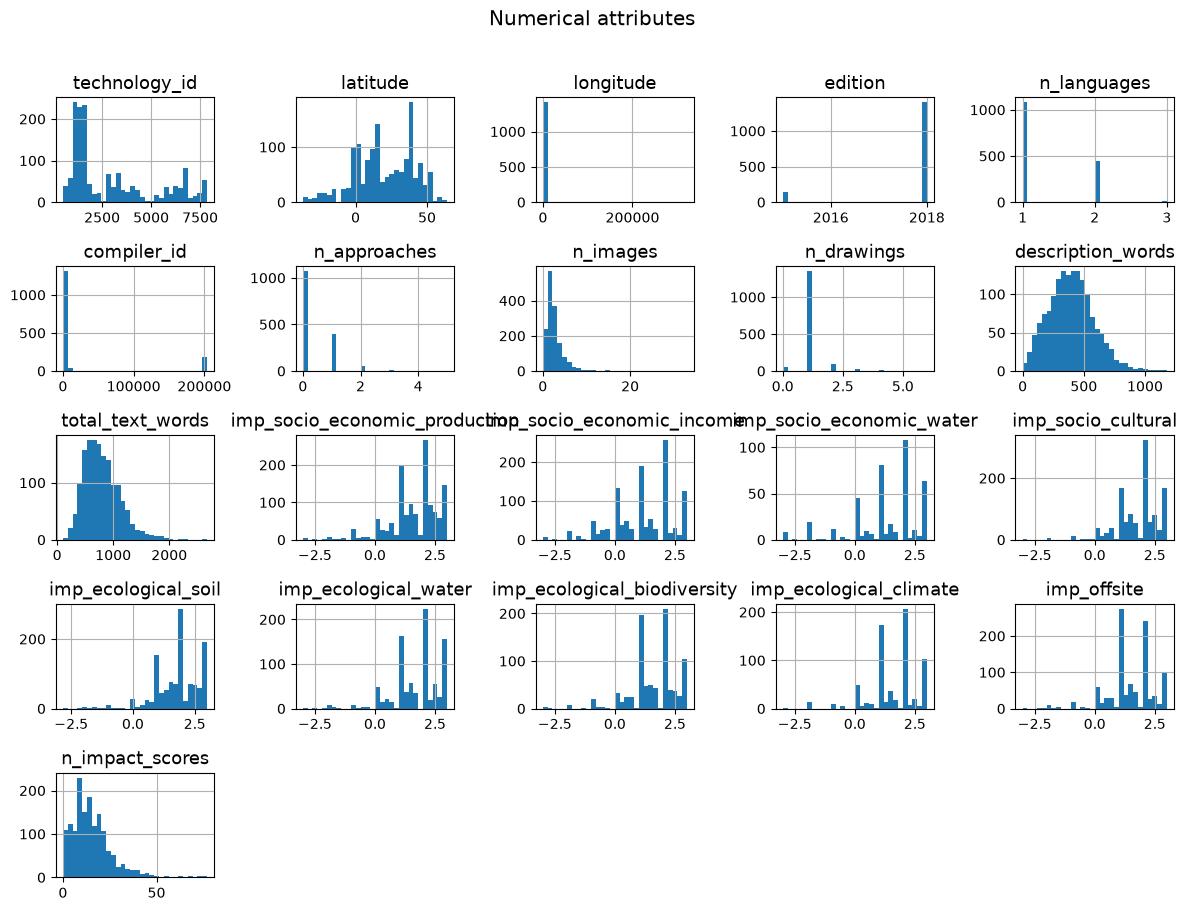

In [15]:
wocat.hist(bins=30, figsize=(12, 9))
plt.suptitle("Numerical attributes", y=1.01)
save_fig("numerical_attribute_histograms")
plt.show()

Two things already stand out:

* Every `imp_*` histogram sits almost entirely to the **right of zero**. Compilers report positive
  impacts nearly all the time. We will come back to this in section 7 — it is the single most
  important property of this dataset.
* `description_words` has a long right tail: some records carry very substantial text.

# 3. Where and When

## 3.1 Geography

In [16]:
top_countries = wocat["country_name"].value_counts().head(15)
top_countries.to_frame("records")

,records
country_name,
Tajikistan,124
Uganda,105
Kenya,74
Ethiopia,72
Nepal,52
Philippines,37
India,37
Morocco,37
Cambodia,37


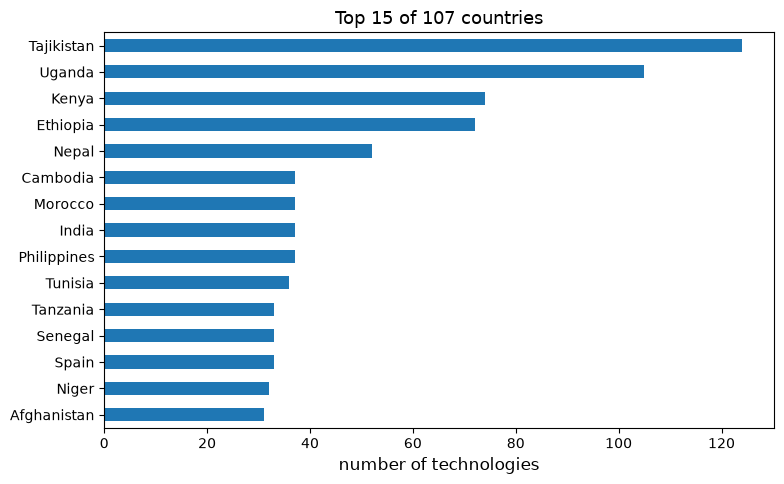

In [17]:
fig, ax = plt.subplots(figsize=(8, 5))
top_countries.sort_values().plot.barh(ax=ax, color="tab:blue")
ax.set_xlabel("number of technologies")
ax.set_ylabel("")
ax.set_title(f"Top 15 of {wocat['country_name'].nunique()} countries")
save_fig("records_per_country")
plt.show()

This is not a map of where sustainable land management happens — it is a map of **where WOCAT
projects have been funded**. Keep it in mind before drawing any geographical conclusion.

Now the actual locations. Each record stores its sites as a set of points; we plotted their centroid:

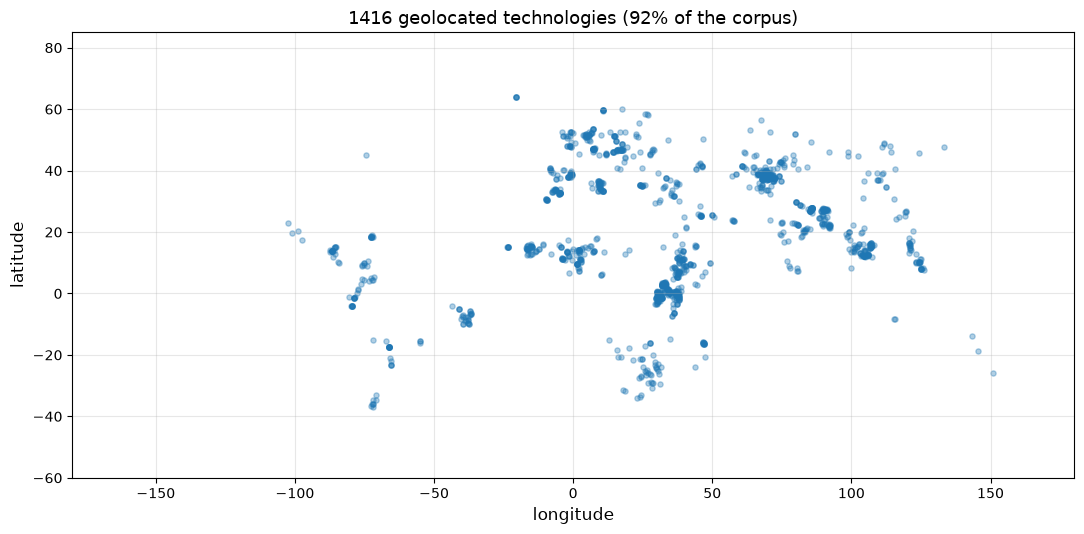

In [18]:
has_coords = wocat.dropna(subset=["latitude", "longitude"])

fig, ax = plt.subplots(figsize=(11, 5.5))
ax.scatter(has_coords["longitude"], has_coords["latitude"], alpha=0.35, s=14, color="tab:blue")
ax.set_xlim(-180, 180)
ax.set_ylim(-60, 85)
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.set_title(f"{len(has_coords)} geolocated technologies "
             f"({len(has_coords) / len(wocat):.0%} of the corpus)")
ax.grid(True, alpha=0.3)
save_fig("world_scatter")
plt.show()

The clustering is severe. That has a direct consequence for modelling: a plain random
train/test split would put neighbouring sites — often documented by the same person in the same
project — on both sides of the split. Any evaluation later in this project should **group by
country**.

## 3.2 Vintage

WOCAT has revised its questionnaire over time. The `edition` tells us which version a record uses,
and it matters because the editions do not ask exactly the same questions:

edition
2015     138
2018    1402


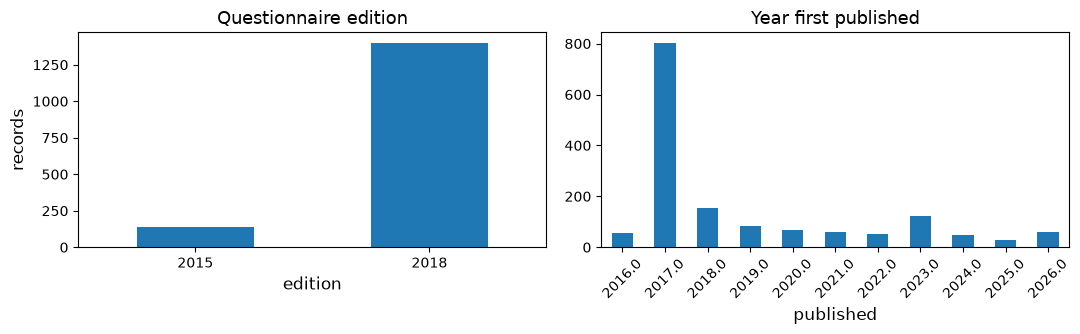

In [19]:
edition_counts = wocat["edition"].value_counts().sort_index()
print(edition_counts.to_string())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
edition_counts.plot.bar(ax=axes[0], color="tab:blue", rot=0)
axes[0].set_title("Questionnaire edition")
axes[0].set_ylabel("records")

year = pd.to_datetime(wocat["published"], format="mixed", utc=True).dt.year
year.value_counts().sort_index().plot.bar(ax=axes[1], color="tab:blue", rot=45)
axes[1].set_title("Year first published")
save_fig("edition_and_year")
plt.show()

# 4. How Complete Is It?

This is the question that decides which projects are possible. WOCAT's questionnaire is long and
most of it is optional, so the interesting fields are often the emptiest ones.

In [20]:
coverage = (wocat.notna().mean().sort_values(ascending=False).to_frame("coverage"))
coverage["non_null"] = wocat.notna().sum()
coverage.style.format({"coverage": "{:.0%}"})

,coverage,non_null
technology_id,100%,1540
n_languages,100%,1540
total_text_words,100%,1540
description_en,100%,1540
description_words,100%,1540
n_drawings,100%,1540
n_images,100%,1540
n_approaches,100%,1540
n_impact_scores,100%,1540
primary_language,100%,1540


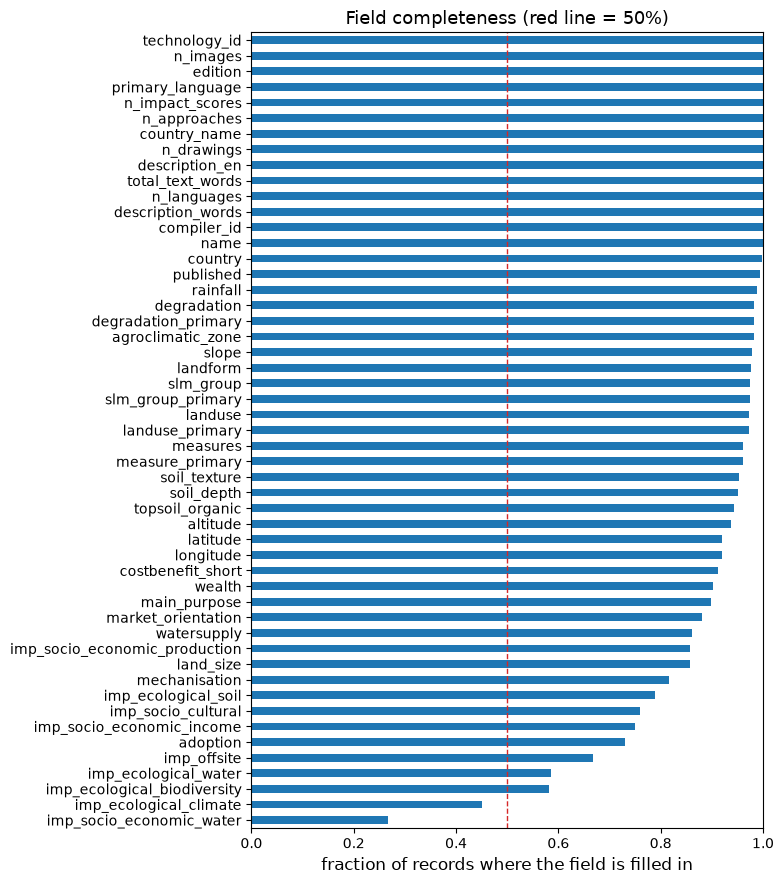

In [21]:
fig, ax = plt.subplots(figsize=(8, 9))
coverage["coverage"].sort_values().plot.barh(ax=ax, color="tab:blue")
ax.axvline(0.5, color="tab:red", linestyle="--", linewidth=1)
ax.set_xlim(0, 1)
ax.set_xlabel("fraction of records where the field is filled in")
ax.set_ylabel("")
ax.set_title("Field completeness (red line = 50%)")
save_fig("field_coverage")
plt.show()

Descriptive fields (country, land use, measures, climate) are nearly complete. The **impact**
fields — the only plausible prediction targets — are the sparse ones. That asymmetry is the
central constraint on this dataset: we have plenty of inputs and few labels.

# 5. Three Modalities in One Record

An unusual property of WOCAT, and the reason it suits a project that has to cover both classical
algorithms and neural networks: the same record carries **structured fields, long free text, and
photographs**.

In [22]:
modalities = pd.DataFrame({
    "records with it": [
        int(wocat["measures"].notna().sum()),
        int((wocat["description_words"] >= 50).sum()),
        int((wocat["n_images"] > 0).sum()),
        int((wocat["n_drawings"] > 0).sum()),
    ]},
    index=["structured questionnaire", "description ≥ 50 words", "≥ 1 photograph",
           "≥ 1 technical drawing"])
modalities["% of corpus"] = (modalities["records with it"] / len(wocat) * 100).round(0)
modalities

,records with it,% of corpus
structured questionnaire,1480,96.0
description ≥ 50 words,1524,99.0
≥ 1 photograph,1450,94.0
≥ 1 technical drawing,1485,96.0


In [23]:
print(f"total words across {len(TEXT_FIELDS)} text fields: {wocat['total_text_words'].sum():,}")
print(f"total photographs:                     {wocat['n_images'].sum():,}")
print(f"records with all three modalities:     "
      f"{((wocat.description_words >= 50) & (wocat.n_images > 0) & wocat.measures.notna()).sum():,}")

total words across 13 text fields: 1,231,964
total photographs:                     4,396
records with all three modalities:     1,399


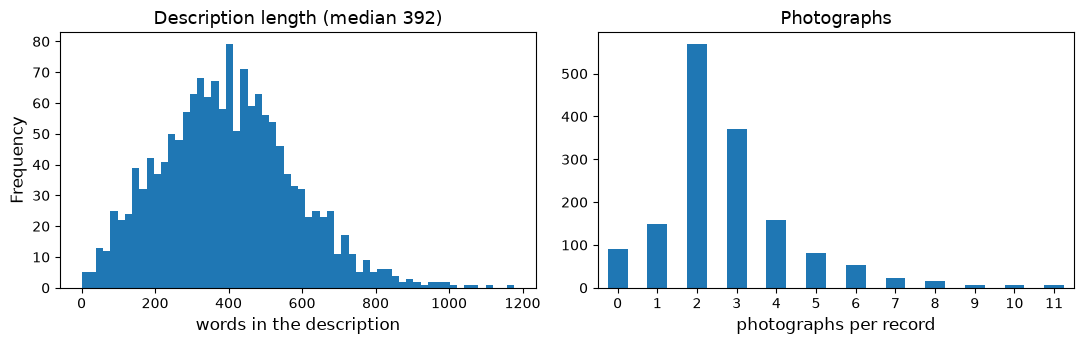

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
wocat["description_words"].plot.hist(bins=60, ax=axes[0], color="tab:blue")
axes[0].set_xlabel("words in the description")
axes[0].set_title(f"Description length (median {wocat.description_words.median():.0f})")

wocat["n_images"].value_counts().sort_index().head(12).plot.bar(
    ax=axes[1], color="tab:blue", rot=0)
axes[1].set_xlabel("photographs per record")
axes[1].set_title("Photographs")
save_fig("modalities")
plt.show()

A median description of a few hundred words, across ~1,500 records, is a real text corpus — enough
to fine-tune a language model on. Nearly every record also has photographs. Both are things a
neural network can use and a classical model on the structured fields cannot.

# 6. What Kind of Practices Are Documented?

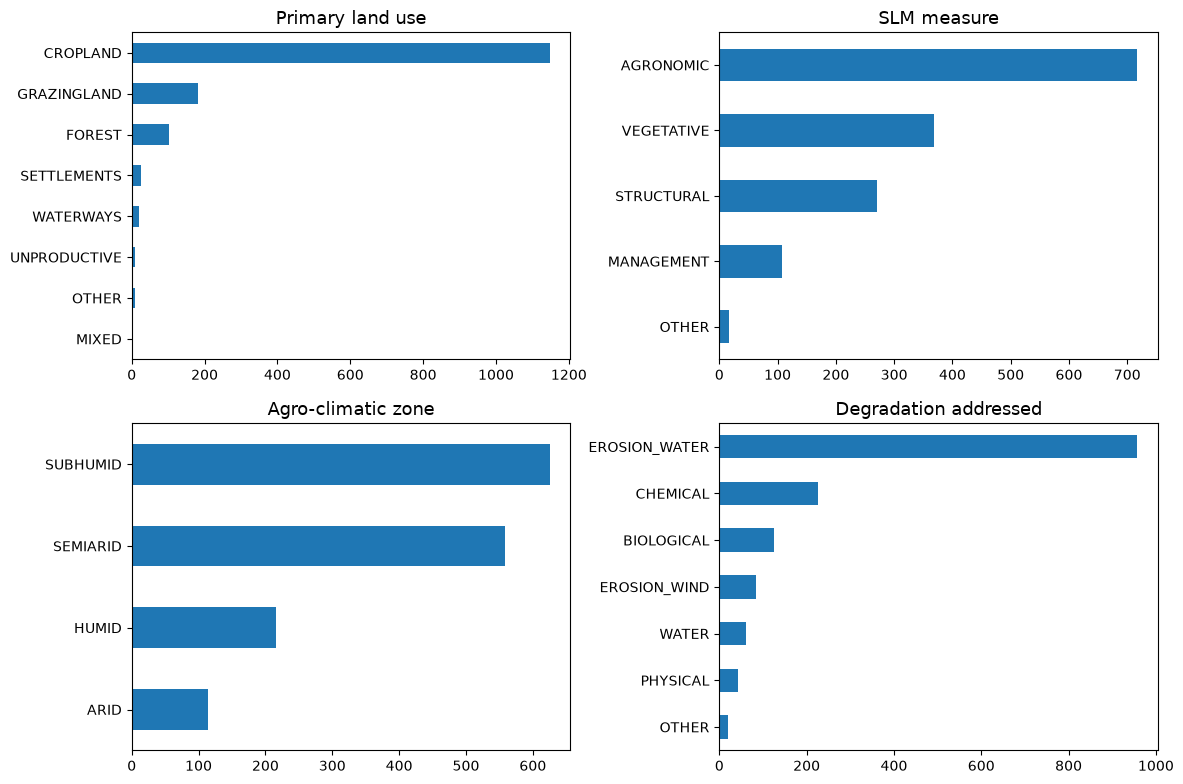

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
for ax, col, title in zip(
        axes.ravel(),
        ["landuse_primary", "measure_primary", "agroclimatic_zone", "degradation_primary"],
        ["Primary land use", "SLM measure", "Agro-climatic zone", "Degradation addressed"]):
    wocat[col].value_counts().sort_values().plot.barh(ax=ax, color="tab:blue")
    ax.set_title(title)
    ax.set_ylabel("")
save_fig("practice_categories")
plt.show()

`slm_group` is the most detailed description of *what kind of practice* this is. It has many more
categories, and a long tail — worth knowing before treating it as a classification target:

26 distinct SLM groups; 10 of them appear in fewer than 25 records


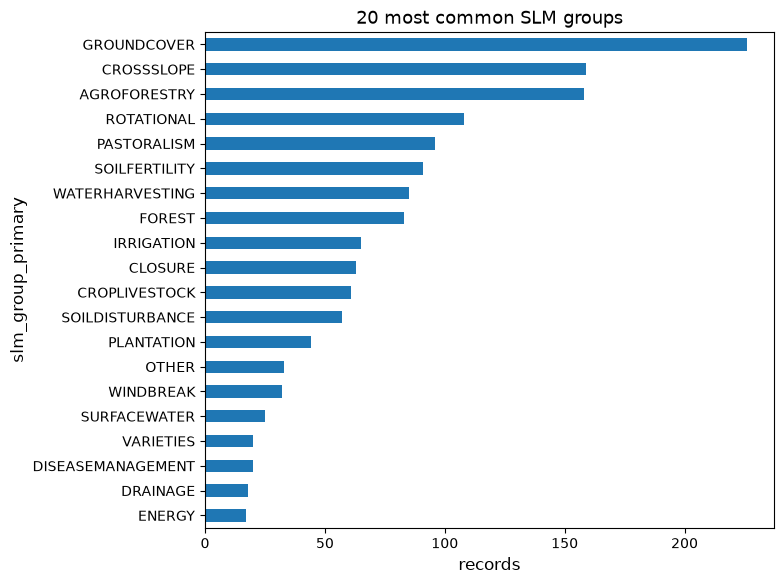

In [26]:
groups = wocat["slm_group_primary"].value_counts()
print(f"{len(groups)} distinct SLM groups; "
      f"{(groups < 25).sum()} of them appear in fewer than 25 records")

fig, ax = plt.subplots(figsize=(8, 6))
groups.head(20).sort_values().plot.barh(ax=ax, color="tab:blue")
ax.set_xlabel("records")
ax.set_title("20 most common SLM groups")
save_fig("slm_groups")
plt.show()

A crosstab is a good way to see whether two categorical fields carry different information, or
essentially the same information twice:

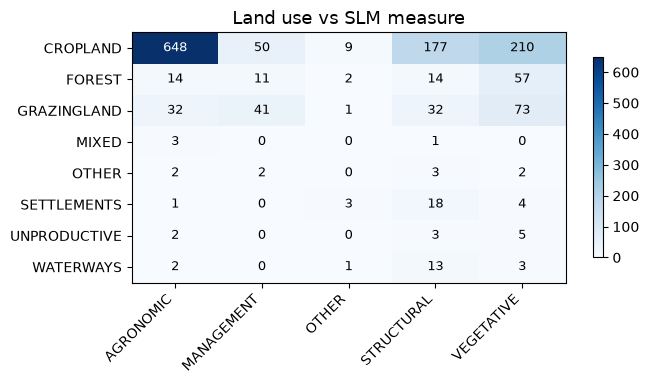

In [27]:
crosstab = pd.crosstab(wocat["landuse_primary"], wocat["measure_primary"])

fig, ax = plt.subplots(figsize=(7, 4))
im = ax.imshow(crosstab.values, cmap="Blues", aspect="auto")
ax.set_xticks(range(len(crosstab.columns)), crosstab.columns, rotation=45, ha="right")
ax.set_yticks(range(len(crosstab.index)), crosstab.index)
for i in range(crosstab.shape[0]):
    for j in range(crosstab.shape[1]):
        value = crosstab.values[i, j]
        ax.text(j, i, value, ha="center", va="center", fontsize=9,
                color="white" if value > crosstab.values.max() * 0.6 else "black")
ax.set_title("Land use vs SLM measure")
fig.colorbar(im, ax=ax, shrink=0.8)
save_fig("landuse_vs_measure")
plt.show()

# 7. The Impact Questionnaire

This is where any prediction target has to come from. WOCAT asks the compiler to rate the impact of
the practice on a **−3 (much worse) to +3 (much better)** scale, across nine thematic blocks.

In [28]:
impact_cols = [c for c in wocat.columns if c.startswith("imp_")]

summary = pd.DataFrame({
    "records scored": wocat[impact_cols].notna().sum(),
    "coverage": wocat[impact_cols].notna().mean(),
    "mean score": wocat[impact_cols].mean(),
    "std": wocat[impact_cols].std(),
}).sort_values("records scored", ascending=False)
summary.style.format({"coverage": "{:.0%}", "mean score": "{:.2f}", "std": "{:.2f}"})

,records scored,coverage,mean score,std
imp_socio_economic_production,1321,86%,1.59,1.04
imp_ecological_soil,1214,79%,1.82,0.91
imp_socio_cultural,1170,76%,1.77,0.88
imp_socio_economic_income,1155,75%,1.12,1.25
imp_offsite,1029,67%,1.43,0.99
imp_ecological_water,903,59%,1.66,1.05
imp_ecological_biodiversity,895,58%,1.55,1.02
imp_ecological_climate,693,45%,1.52,1.07
imp_socio_economic_water,412,27%,1.24,1.41


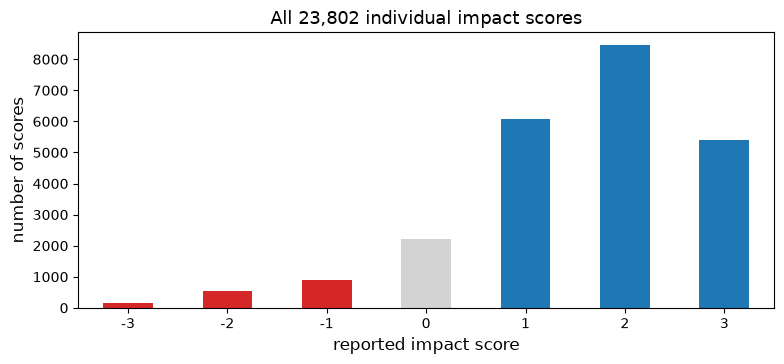

84% of all scores are positive (≥ +1)
7% are negative


In [29]:
distribution = impact_scores["value"].value_counts().sort_index()
colors = ["tab:red" if s < 0 else "lightgray" if s == 0 else "tab:blue" for s in distribution.index]

fig, ax = plt.subplots(figsize=(8, 3.8))
distribution.plot.bar(ax=ax, color=colors, rot=0)
ax.set_xlabel("reported impact score")
ax.set_ylabel("number of scores")
ax.set_title(f"All {len(impact_scores):,} individual impact scores")
save_fig("impact_score_distribution")
plt.show()

share = impact_scores["value"]
print(f"{(share >= 1).mean():.0%} of all scores are positive (≥ +1)")
print(f"{(share < 0).mean():.0%} are negative")

**This is the most important plot in the notebook.** WOCAT documents practices that someone
thought were worth sharing, and the same person rates the outcome. There are almost no failures in
the database, and no record of what would have happened without the intervention.

Two consequences we have to design around:

1. A target built by splitting these scores at **zero** would be nearly constant. If we want a
   classification target we must split at the **median** instead, and ask "better than typical?"
   rather than "good or bad?".
2. Nothing here supports a causal claim. Any model predicts the *reported* impact, not the effect
   of the practice.

Do the impact blocks measure different things, or does a compiler who is enthusiastic about one
tend to be enthusiastic about all of them?

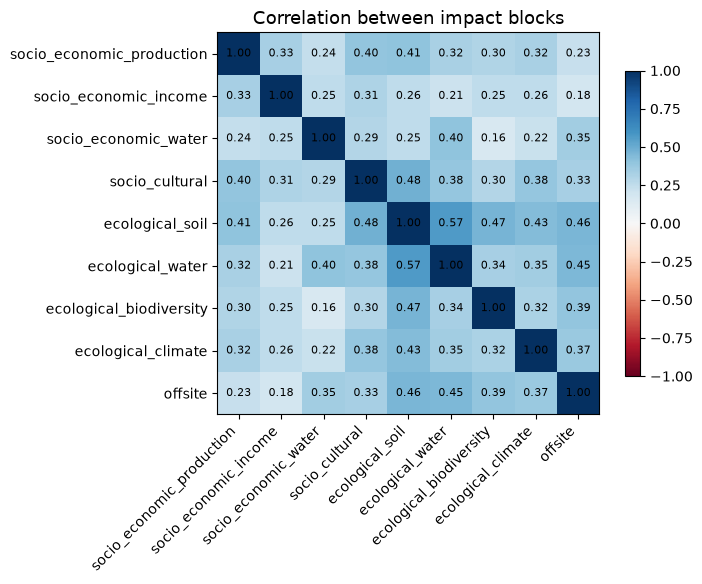

In [30]:
correlations = wocat[impact_cols].corr()

fig, ax = plt.subplots(figsize=(7.5, 6))
im = ax.imshow(correlations, cmap="RdBu", vmin=-1, vmax=1)
labels = [c.replace("imp_", "") for c in impact_cols]
ax.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
ax.set_yticks(range(len(labels)), labels)
for i in range(len(labels)):
    for j in range(len(labels)):
        ax.text(j, i, f"{correlations.values[i, j]:.2f}", ha="center", va="center", fontsize=8)
ax.set_title("Correlation between impact blocks")
fig.colorbar(im, ax=ax, shrink=0.8)
save_fig("impact_correlations")
plt.show()

The blocks are all positively correlated with each other, often strongly. A compiler who reports a
large soil benefit tends to report a large production benefit too. That is consistent with the
blocks measuring genuinely related things — and equally consistent with a per-person rating style.
The next section shows which explanation the data favours.

# 8. Who Wrote It?

Each record names its compiler. This is not usually an interesting field, but here it turns out to
be one of the most informative columns in the table.

454 distinct compilers for 1,540 records
the most prolific wrote 90 records
the top 20 wrote 441 between them (29% of the corpus)


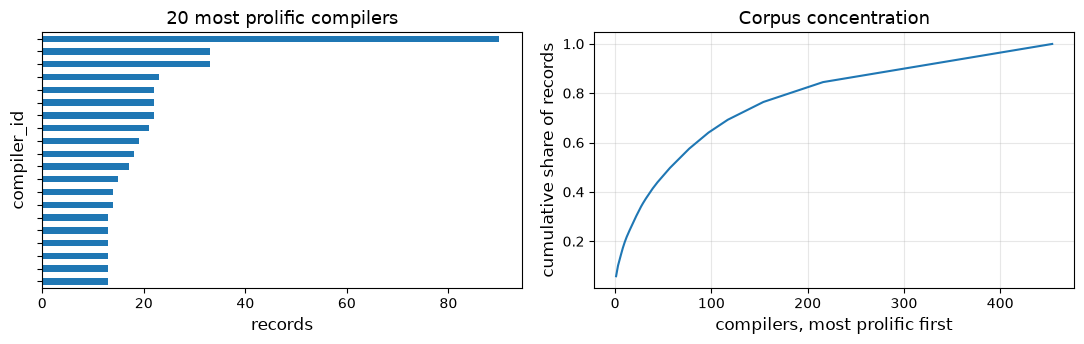

In [31]:
per_compiler = wocat["compiler_id"].value_counts()
print(f"{len(per_compiler)} distinct compilers for {len(wocat):,} records")
print(f"the most prolific wrote {per_compiler.iloc[0]} records")
print(f"the top 20 wrote {per_compiler.head(20).sum():,} between them "
      f"({per_compiler.head(20).sum() / len(wocat):.0%} of the corpus)")

fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
per_compiler.head(20).sort_values().plot.barh(ax=axes[0], color="tab:blue")
axes[0].set_xlabel("records")
axes[0].set_title("20 most prolific compilers")
axes[0].set_yticklabels([])

cumulative = per_compiler.cumsum() / len(wocat)
axes[1].plot(range(1, len(cumulative) + 1), cumulative.values, color="tab:blue")
axes[1].set_xlabel("compilers, most prolific first")
axes[1].set_ylabel("cumulative share of records")
axes[1].set_title("Corpus concentration")
axes[1].grid(True, alpha=0.3)
save_fig("compilers")
plt.show()

Now the diagnostic. If the impact scores mostly reflect the land, then compilers who documented
many records should not differ much in their average score. Let's check:

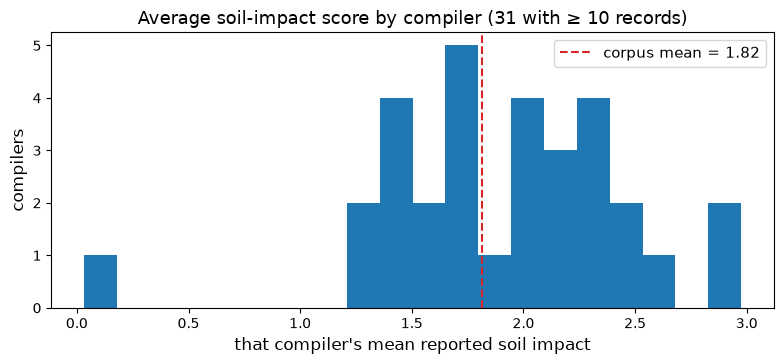

compiler means range from 0.03 to 2.98
on a scale where the whole corpus averages 1.82


In [32]:
prolific = per_compiler[per_compiler >= 10].index
by_compiler = (wocat[wocat.compiler_id.isin(prolific)]
               .groupby("compiler_id")["imp_ecological_soil"]
               .agg(["count", "mean"]).dropna())

fig, ax = plt.subplots(figsize=(8, 3.8))
ax.hist(by_compiler["mean"], bins=20, color="tab:blue")
ax.axvline(wocat["imp_ecological_soil"].mean(), color="tab:red", linestyle="--",
           label=f"corpus mean = {wocat['imp_ecological_soil'].mean():.2f}")
ax.set_xlabel("that compiler's mean reported soil impact")
ax.set_ylabel("compilers")
ax.set_title(f"Average soil-impact score by compiler ({len(by_compiler)} with ≥ 10 records)")
ax.legend()
save_fig("compiler_bias")
plt.show()

print(f"compiler means range from {by_compiler['mean'].min():.2f} to {by_compiler['mean'].max():.2f}")
print(f"on a scale where the whole corpus averages {wocat['imp_ecological_soil'].mean():.2f}")

Setting aside the one compiler at the far left, the averages run from about 1.2 to 3.0 — a spread
of nearly two points on a seven-point scale, among people who each documented at least ten
records, so it is not small-sample noise. **Who
fills in the questionnaire is a first-order influence on the reported impact.** Any model trained
on these labels will learn some of that, and any claim of the form "SLM practices improve X" made
from this data is partly a claim about its authors.

# 9. So What Should We Do With This Data?

Pulling the observations together:

| Observation | Where | Consequence |
|---|---|---|
| ~1,500 records, ~45 useful columns | §2 | Small data. Classical models are appropriate; deep tabular models are not. |
| Almost entirely categorical | §2 | One-hot / ordinal encoding, tree ensembles as the natural baseline. |
| Severe geographic clustering | §3.1 | Group the cross-validation by country, or every score is inflated. |
| Inputs ~95% complete, labels ~50–85% | §4 | The **target**, not the features, limits the sample size. |
| Text + images on nearly every record | §5 | This is what justifies a neural-network module at all. |
| 84% of impact scores are positive | §7 | Split targets at the median, never at zero. No failures are recorded. |
| Impact blocks strongly intercorrelated | §7 | Don't use one impact block to predict another — same form, same rater. |
| Compiler explains a full point of score | §8 | Reported impact is partly a property of the author. |

### What looks promising

**Classify the practice from its description.** `description` → `measure_primary` (4 classes) or
`slm_group_primary` (many classes). The labels are clean and near-complete, the input is a real
text corpus, and there is an obvious reason a language model should beat bag-of-words. It also has
a plausible use: helping WOCAT tag new submissions.

**Retrieve comparable documented cases.** Given a site's environment, find the technologies
documented in similar contexts. This makes no causal claim, so the biases above do not invalidate
it, and it is close to what a practitioner would actually want.

**Quantify the reporting bias itself.** Section 8 is a sketch; doing it properly — decomposing the
variance across compiler, country, environment and practice — would be genuinely useful to WOCAT.

### What to be careful about

Predicting *impact* is the obvious idea and the data does not really support it. There are no
documented failures and no counterfactuals, so nothing distinguishes "this practice works" from
"this practice was worth writing up". Before committing to that direction, run the check that
matters: fit a model on the environment alone, then on the environment plus the practice, and see
whether knowing the practice adds anything. Here is that test, in one cell:

In [33]:
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedGroupKFold, cross_val_score
from sklearn.preprocessing import OneHotEncoder

TARGET = "imp_ecological_soil"
ENVIRONMENT = ["agroclimatic_zone", "rainfall", "altitude", "slope", "landform",
               "soil_depth", "soil_texture", "topsoil_organic", "landuse_primary"]
PRACTICE = ["measure_primary", "slm_group_primary", "main_purpose"]

data = wocat.dropna(subset=[TARGET, "country"]).copy()
# "better than typical", because splitting at zero would be nearly constant (§7)
y = (data[TARGET] >= data[TARGET].median()).astype(int).values
groups = data["country"].values

def encode(columns):
    return OneHotEncoder(handle_unknown="ignore").fit_transform(
        data[columns].astype(str)).toarray()

def grouped_score(X):
    splits = list(StratifiedGroupKFold(5, shuffle=True, random_state=42).split(X, y, groups))
    forest = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
    return cross_val_score(forest, X, y, cv=splits, scoring="f1_macro").mean()

X_env = encode(ENVIRONMENT)
baseline = cross_val_score(
    DummyClassifier(strategy="most_frequent"), X_env, y,
    cv=list(StratifiedGroupKFold(5, shuffle=True, random_state=42).split(X_env, y, groups)),
    scoring="f1_macro").mean()

print(f"n = {len(y)}, grouped by {len(set(groups))} countries\n")
print(f"baseline (majority class)   {baseline:.3f}")
print(f"environment only            {grouped_score(X_env):.3f}")
print(f"practice only               {grouped_score(encode(PRACTICE)):.3f}")
print(f"environment + practice      {grouped_score(encode(ENVIRONMENT + PRACTICE)):.3f}")

n = 1211, grouped by 100 countries

baseline (majority class)   0.363


environment only            0.503


practice only               0.498


environment + practice      0.492


Knowing which practice was applied adds very little to knowing where the site is and what it is
like. That is the number to sit with before designing a project around predicting impact — and it
is exactly the kind of check worth running early, while it is still cheap to change direction.

---

### Where to go next

1. Pick a target and justify it with sections 4 and 7 rather than with intuition.
2. Build the feature matrix and fix the grouped train/test split **once**, then reuse it everywhere.
3. Establish classical baselines — logistic regression, random forest, gradient boosting — with
   feature importances, before reaching for anything neural.
4. Only then bring in the text and the images, and measure what they add over the baseline.